# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [3]:
# Repartition de y (indice : value_counts + map vers CLASSES)
# On regarde d'abord si les classes sont equilibrees ou non
repartition = y.map({0: CLASSES[0], 1: CLASSES[1]}).value_counts()
print(repartition)
print("\nProportion diabetiques : {:.1%}".format((y == 1).mean()))
# -> ~35% de diabetiques : les classes sont desequilibrees, il faudra donc
#    regarder le rappel et pas seulement l'accuracy

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64

Proportion diabetiques : 34.9%


## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# stratify=y pour garder la meme proportion de diabetiques dans train et test
# random_state=42 pour que le decoupage soit toujours le meme (resultats reproductibles)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Creer et entrainer l'arbre
# max_depth=3 pour garder un arbre simple et lisible (et eviter le surapprentissage)
# min_samples_leaf=10 : au moins 10 patientes par feuille, sinon on colle trop aux donnees
arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,
                               criterion="gini", random_state=0)
arbre.fit(X_train, y_train)
print(f"train : {len(X_train)} | test : {len(X_test)}")

train : 576 | test : 192


## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique      0.750     0.840     0.792       125
    diabetique      0.615     0.478     0.538        67

      accuracy                          0.714       192
     macro avg      0.683     0.659     0.665       192
  weighted avg      0.703     0.714     0.704       192



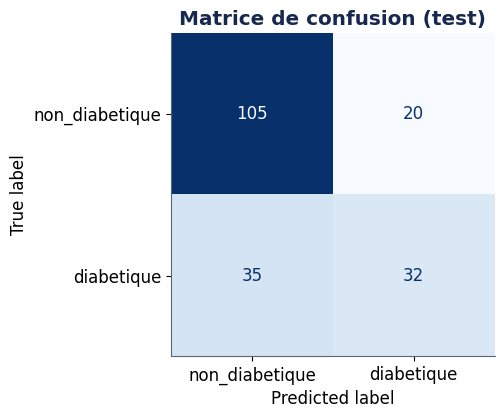

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# On compare accuracy train vs test : si train >> test, c'est du surapprentissage
print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")

y_pred = arbre.predict(X_test)
# Le rapport donne precision / rappel / f1 pour chaque classe
# -> on va surtout regarder la ligne "diabetique"
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

# Matrice de confusion : les faux negatifs (diabetiques predites saines) sont en bas a gauche
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion (test)")
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

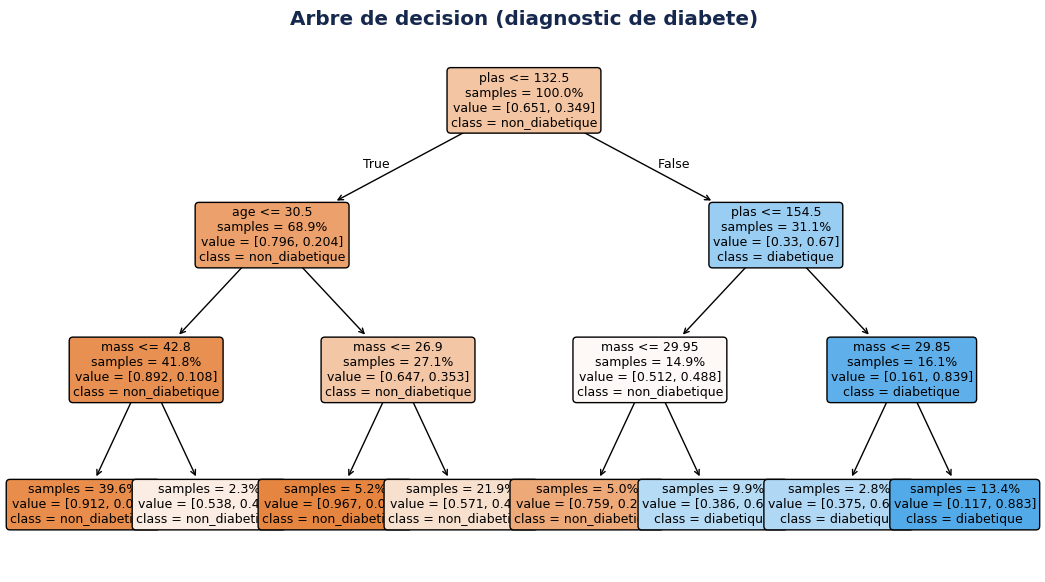

In [6]:
from sklearn.tree import plot_tree

# On trace l'arbre : chaque noeud est une question du type "variable <= seuil ?"
# La classe majoritaire de chaque feuille donne la prediction
fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True,
          rounded=True, fontsize=9, impurity=False, proportion=True, ax=ax)
ax.set_title("Arbre de decision (diagnostic de diabete)")
plt.show()
# On voit que la premiere separation se fait sur 'plas' (le glucose) : c'est bien
# la variable la plus discriminante

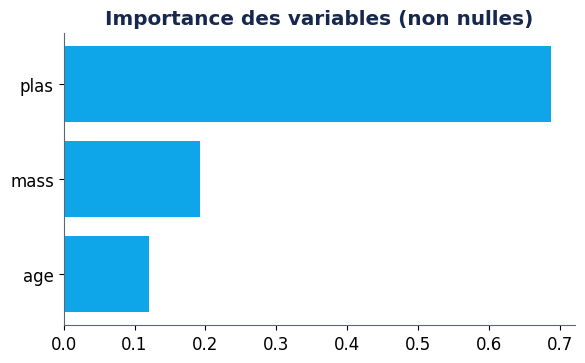

plas    0.687
mass    0.193
age     0.121
dtype: float64

In [7]:
# feature_importances_ : a quel point chaque variable a servi a separer les classes
# On ne garde que les variables reellement utilisees (importance > 0) et on trie
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
# barh de imp
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables (non nulles)")
plt.show()
imp.sort_values(ascending=False).round(3)   # les plus importantes en haut

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [8]:
ech = X_test.head(5)
# pred et proba, puis DataFrame comparatif
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]   # proba de la classe 1 = diabetique
# On met cote a cote le vrai diagnostic, la prediction et la proba :
# la proba est utile car on pourrait changer le seuil (ex : alerter des 0.3) pour
# rater moins de diabetiques
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_diabetique": proba.round(2),
}, index=ech.index)

,reel,predit,proba_diabetique
635,diabetique,non_diabetique,0.43
698,non_diabetique,non_diabetique,0.09
637,non_diabetique,non_diabetique,0.09
402,diabetique,diabetique,0.61
425,diabetique,diabetique,0.88


## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?

## Reponses

**Accuracy test et matrice de confusion.**
Sur le test je trouve une accuracy d'environ 0.71, alors qu'en train elle est
autour de 0.78. Il y a donc un petit ecart train/test, mais pour un arbre limite
a `max_depth=3` ca reste correct, on n'est pas vraiment en surapprentissage.
En regardant la matrice de confusion, le modele reconnait bien les non-diabetiques
mais se trompe beaucoup sur les vraies diabetiques : a peu pres une malade sur
deux est classee "non diabetique" (ce sont les faux negatifs).

**Rappel sur `diabetique` et pourquoi il est important.**
Le rappel de la classe diabetique est faible (~0.48), ca veut dire que l'arbre ne
retrouve que la moitie des patientes vraiment malades. Or ici le faux negatif
(dire a une malade qu'elle va bien) est plus grave qu'une fausse alerte, parce
qu'on peut toujours refaire un test derriere pour confirmer. Du coup c'est le
rappel qu'on veut maximiser, quitte a perdre un peu en precision. On pourrait par
exemple baisser le seuil sur le `predict_proba` pour attraper plus de cas positifs.

**Variables les plus importantes.**
D'apres `feature_importances_`, l'arbre utilise surtout :
1. `plas` (le taux de glucose), de tres loin la plus importante (~0.69) ;
2. `mass` (l'IMC, ~0.19) ;
3. `age` (~0.12).

Ca me parait logique vu que ce sont des facteurs de risque connus du diabete.

In [9]:
# Bonus : faire varier max_depth (2, 3, 6, None) -> ou commence le surapprentissage ?
resultats = []
for prof in [2, 3, 6, None]:
    a = DecisionTreeClassifier(max_depth=prof, min_samples_leaf=10, random_state=0)
    a.fit(X_train, y_train)
    resultats.append({
        "max_depth": str(prof),
        "acc_train": round(a.score(X_train, y_train), 3),
        "acc_test": round(a.score(X_test, y_test), 3),
        "ecart": round(a.score(X_train, y_train) - a.score(X_test, y_test), 3),
    })
res = pd.DataFrame(resultats)
print(res.to_string(index=False))
print("\nOn voit que plus max_depth augmente, plus l'accuracy train monte,")
print("mais l'ecart avec le test se creuse : c'est le debut du surapprentissage")
print("(l'arbre commence a apprendre par coeur les donnees d'entrainement).")

max_depth  acc_train  acc_test  ecart
        2      0.760     0.708  0.052
        3      0.783     0.714  0.069
        6      0.830     0.755  0.075
     None      0.835     0.766  0.069

On voit que plus max_depth augmente, plus l'accuracy train monte,
mais l'ecart avec le test se creuse : c'est le debut du surapprentissage
(l'arbre commence a apprendre par coeur les donnees d'entrainement).


## 6. Modeles d'ensemble : Random Forest & XGBoost

Un seul arbre est **interpretable** mais peu performant. Les methodes d'**ensemble**
combinent beaucoup d'arbres pour gagner en robustesse :

- **Random Forest** : de nombreux arbres entraines en parallele sur des
  echantillons/variables tires au hasard (*bagging*), puis on **moyenne** leurs votes.
- **XGBoost** (*Extreme Gradient Boosting*) : des arbres construits
  **sequentiellement**, chacun corrigeant les erreurs du precedent (*boosting*),
  avec regularisation. C'est une reference sur les donnees tabulaires.

On garde le meme split train/test pour comparer equitablement.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score

# Random Forest = plein d'arbres en parallele, on moyenne leurs votes (bagging)
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=5, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# XGBoost = arbres construits l'un apres l'autre, chacun corrige les erreurs du
# precedent (boosting). learning_rate faible = on avance a petits pas
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                    subsample=0.9, colsample_bytree=0.9,
                    eval_metric="logloss", random_state=0)
xgb.fit(X_train, y_train)

print(f"Random Forest -> acc test : {rf.score(X_test, y_test):.3f}")
print(f"XGBoost       -> acc test : {xgb.score(X_test, y_test):.3f}")

Random Forest -> acc test : 0.745
XGBoost       -> acc test : 0.740


             modele  acc_test  rappel_diabetique  f1_diabetique
Arbre (max_depth=3)     0.714              0.478          0.538
      Random Forest     0.745              0.567          0.608
            XGBoost     0.740              0.597          0.615


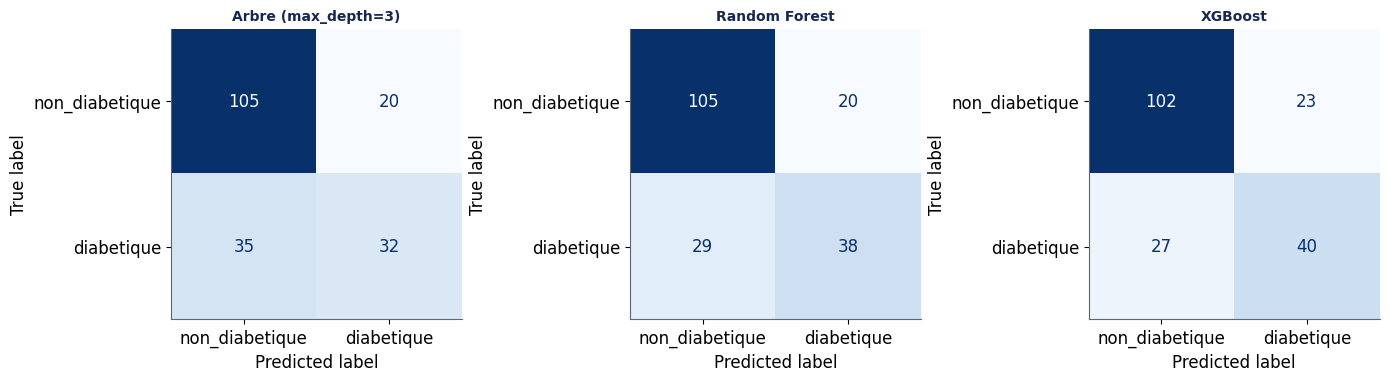

In [11]:
# On compare les 3 modeles. On regarde surtout le rappel sur 'diabetique'
# (classe 1), car c'est celui qu'on veut le plus eleve possible
modeles = {"Arbre (max_depth=3)": arbre, "Random Forest": rf, "XGBoost": xgb}
compar = []
for nom, m in modeles.items():
    yp = m.predict(X_test)
    compar.append({
        "modele": nom,
        "acc_test": round(m.score(X_test, y_test), 3),
        "rappel_diabetique": round(recall_score(y_test, yp), 3),
        "f1_diabetique": round(f1_score(y_test, yp), 3),
    })
compar = pd.DataFrame(compar)
print(compar.to_string(index=False))
# -> les modeles d'ensemble ratent moins de diabetiques que l'arbre seul

# Matrices de confusion cote a cote pour bien visualiser la difference
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nom, m) in zip(axes, modeles.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom, fontsize=10)
plt.tight_layout()
plt.show()

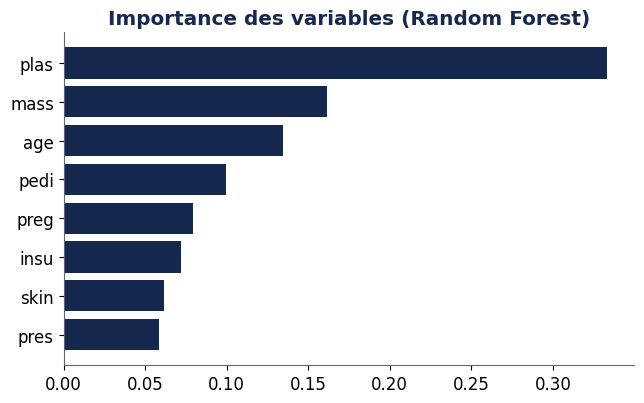

plas    0.333
mass    0.162
age     0.135
pedi    0.100
preg    0.079
insu    0.072
skin    0.062
pres    0.058
dtype: float64

In [12]:
# Comme l'arbre n'est plus lisible avec 300 arbres, on regarde l'importance des
# variables pour interpreter la foret (elle est moyennee sur tous les arbres)
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.barh(imp_rf.index, imp_rf.values, color=NAVY)
ax.set_title("Importance des variables (Random Forest)")
plt.tight_layout()
plt.show()
imp_rf.sort_values(ascending=False).round(3)
# -> on retrouve 'plas' en tete, comme pour l'arbre simple

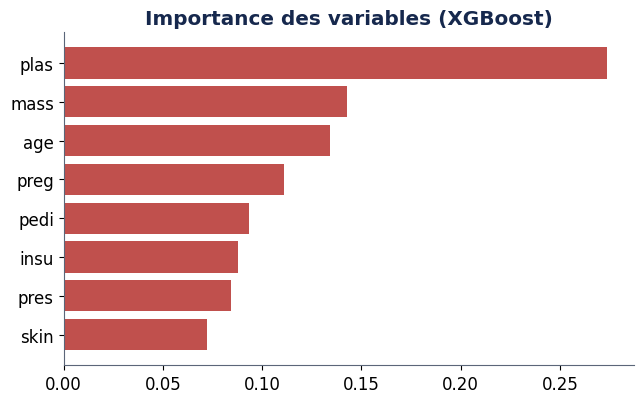

plas    0.274
mass    0.143
age     0.134
preg    0.111
pedi    0.093
insu    0.088
pres    0.084
skin    0.072
dtype: float32

In [13]:
# Meme chose pour XGBoost : on verifie que les variables importantes sont coherentes
imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.barh(imp_xgb.index, imp_xgb.values, color=RED)
ax.set_title("Importance des variables (XGBoost)")
plt.tight_layout()
plt.show()
imp_xgb.sort_values(ascending=False).round(3)
# -> encore 'plas' en premier : les 3 modeles sont d'accord sur l'essentiel

### Conclusion sur les modeles d'ensemble

- **Est-ce qu'on gagne en accuracy ?** Un peu oui. La Random Forest et XGBoost
  font mieux que l'arbre tout seul, et surtout ils ratent moins de diabetiques
  (le rappel monte), ce qui est justement ce qu'on cherche ici.
- **Est-ce qu'on perd en lisibilite ?** Clairement. Un seul arbre on peut le lire
  comme une suite de regles, mais une foret de 300 arbres ou un modele XGBoost
  on ne peut plus vraiment expliquer une decision precise. Il nous reste juste
  l'importance des variables pour comprendre, et on retrouve toujours `plas` en
  tete, puis `mass`, `age` et `pedi`.
- **Bilan.** Je garderais l'arbre simple quand on veut expliquer une decision, et
  un modele d'ensemble (RF ou XGBoost) quand on veut surtout de bonnes
  performances. Les deux ne servent pas exactement au meme but.